# Titanic Exploratory Data Analysis

## Who survived and why?

This notebook explores the Titanic dataset to understand the factors associated with passenger survival.

The analysis focuses on data quality, missing values, demographics, and socioeconomic factors. This is an exploratory analysis only; no machine-learning models are used.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "data/Titanic-Dataset.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Dataset shape:", df.shape)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nSummary statistics:")
display(df.describe())


Dataset shape: (891, 12)

Data types:


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


Missing values:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Summary statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
# Make a copy so the original dataframe remains unchanged.
clean = df.copy()

# Age has 177 missing values.
# We use the median because age is numeric and the median is less
# affected by extreme values than the mean.
clean["AgeMissing"] = clean["Age"].isna()
clean["Age"] = clean["Age"].fillna(clean["Age"].median())

# Cabin is missing for most passengers (687 of 891).
# We don't invent cabin values. Instead, create a simple indicator
# showing whether a cabin was recorded.
clean["HasCabin"] = clean["Cabin"].notna()

# Only two Embarked values are missing.
# Since this is categorical, use the most common value (mode).
clean["Embarked"] = clean["Embarked"].fillna(clean["Embarked"].mode()[0])

# Check the result.
print("Missing values after cleaning:")
display(clean.isnull().sum())

Missing values after cleaning:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
AgeMissing       0
HasCabin         0
dtype: int64

In [5]:
# Overall survival rate
survival_rate = clean["Survived"].mean()

print(f"Overall survival rate: {survival_rate:.1%}")

Overall survival rate: 38.4%


In [6]:
# Survival rate by sex
survival_by_sex = (
    clean.groupby("Sex")["Survived"]
    .mean()
    .sort_values(ascending=False)
)

display((survival_by_sex * 100).round(1).to_frame("Survival Rate (%)"))

,Survival Rate (%)
Sex,
female,74.2
male,18.9


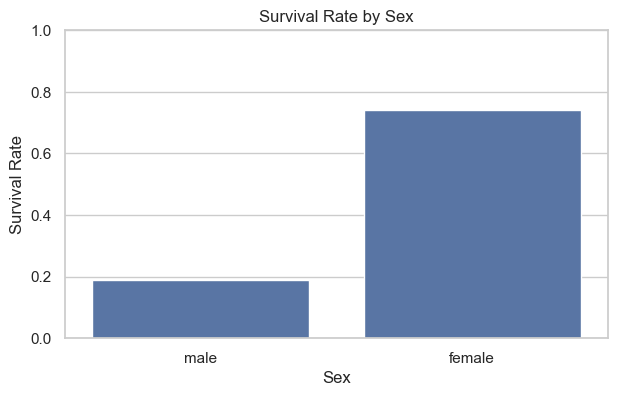

In [7]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=clean,
    x="Sex",
    y="Survived",
    errorbar=None
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

In [8]:
# Survival rate by passenger class
survival_by_class = (
    clean.groupby("Pclass")["Survived"]
    .mean()
    .sort_index()
)

display((survival_by_class * 100).round(1).to_frame("Survival Rate (%)"))

,Survival Rate (%)
Pclass,
1,63.0
2,47.3
3,24.2


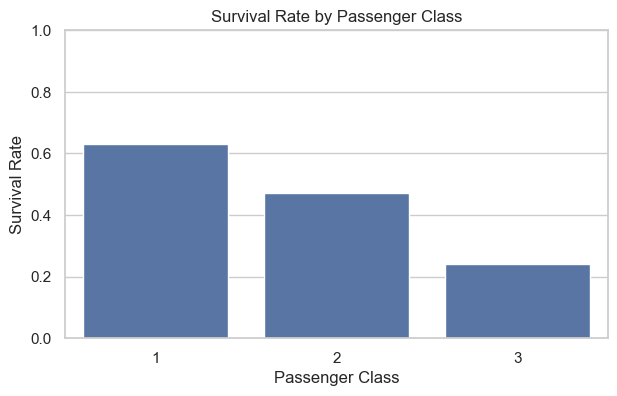

In [9]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=clean,
    x="Pclass",
    y="Survived",
    errorbar=None
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

In [10]:
# Survival rate by sex and passenger class
sex_class_survival = (
    clean.groupby(["Sex", "Pclass"])["Survived"]
    .mean()
    .unstack()
)

display((sex_class_survival * 100).round(1))

Pclass,1,2,3
Sex,,,
female,96.8,92.1,50.0
male,36.9,15.7,13.5


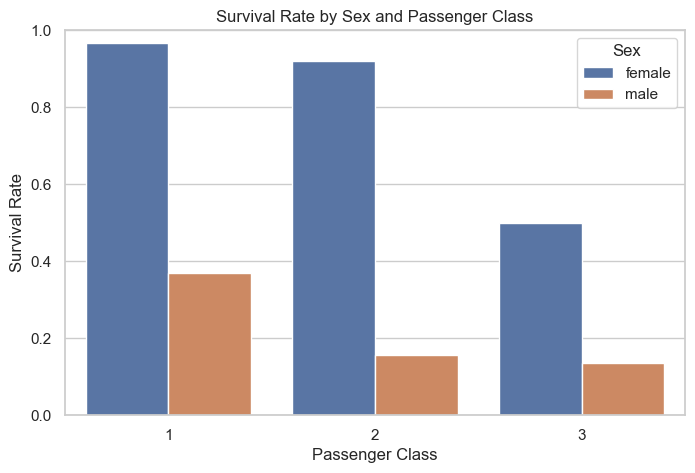

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=clean,
    x="Pclass",
    y="Survived",
    hue="Sex",
    errorbar=None
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

plt.show()

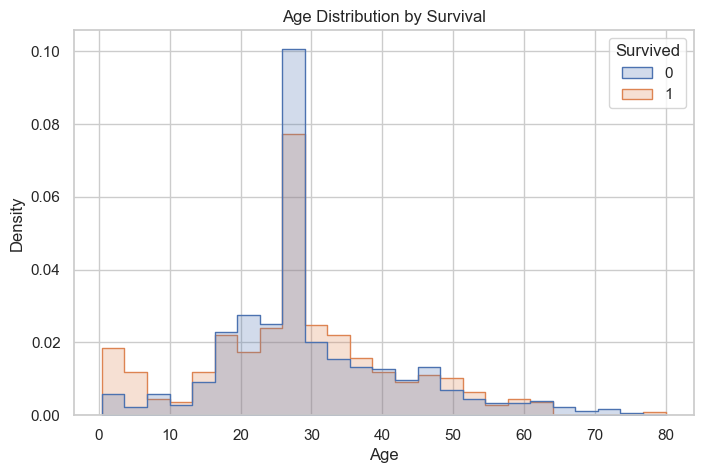

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=clean,
    x="Age",
    hue="Survived",
    bins=25,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Density")

plt.show()

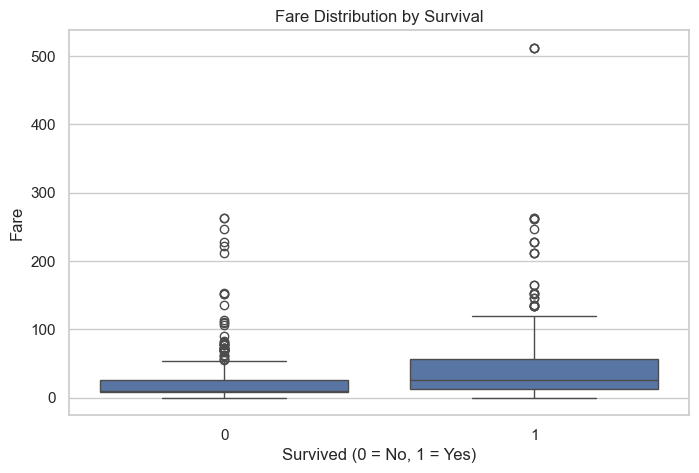

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean,
    x="Survived",
    y="Fare"
)

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.show()

## Findings

The Titanic data show a strong survival gradient by sex and passenger class. Women survived at much higher rates than men, while first-class passengers survived more often than second- and third-class passengers. The interaction matters: class differences remain visible within sex, so “who survived” is better explained by overlapping demographic and socioeconomic factors than by one variable alone. Fare supports the same story because higher-fare passengers generally had better survival outcomes, although fare is closely related to class and should not be treated as an independent cause. Age adds context rather than overturning the main pattern: survivors were not simply the youngest passengers. Missing Age values were median-imputed, while sparse Cabin information was represented only through whether a cabin/deck value was observed. Overall, survival was highly unequal across passenger groups, with women and higher-class passengers advantaged. Next, I would test these relationships while accounting for age and family structure.

## What I would do next

With more time, I would investigate family size and passenger titles, examine whether missingness itself contains useful information, and quantify uncertainty around the observed group differences. I would also test whether the strong sex and class patterns remain after accounting for age and family structure.

Only after completing that analysis would I move to a simple, well-validated machine-learning baseline.